In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("../../DataSet/Mall_Customers.csv")
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [15]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [16]:
df.tail()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [20]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [21]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
195    False
196    False
197    False
198    False
199    False
Length: 200, dtype: bool

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
dp = df[df.duplicated(keep=False)]
dp

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)


In [7]:
df["Annual Income (k$)"].mean()

np.float64(60.56)

In [8]:
df["Annual Income (k$)"].median()

61.5

In [9]:
df["Annual Income (k$)"].min()

15

In [10]:
df["Annual Income (k$)"].max()

137

In [11]:
df["Annual Income (k$)"].std()

26.264721165271254

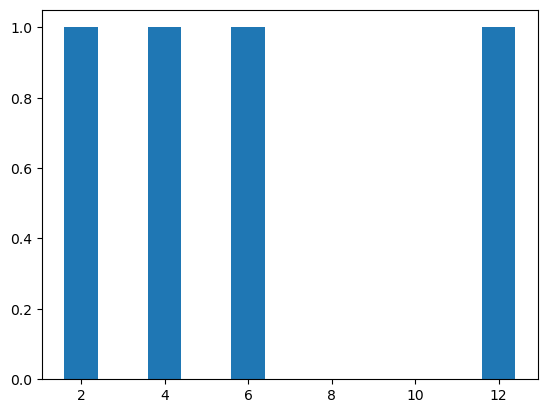

In [12]:
plt.bar(df["Annual Income (k$)"].value_counts(), height=True)
plt.show()

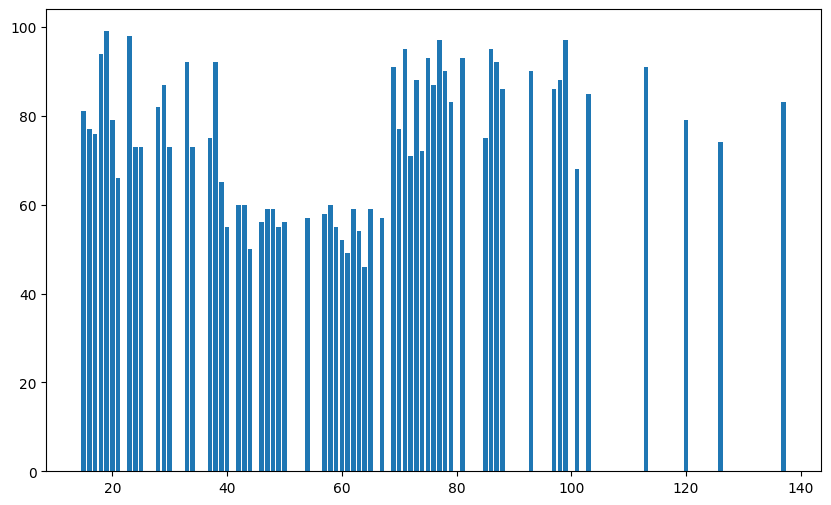

In [30]:
plt.figure(figsize=(10,6))
plt.bar(df["Annual Income (k$)"],df["Spending Score (1-100)"])
plt.show()

In [13]:
target_group = df[(df['Annual Income (k$)'] >= 40) & 
                  (df['Annual Income (k$)'] <= 70) & 
                  (df['Spending Score (1-100)'] > 60)]

print(target_group.shape)   
print(target_group.head())

(2, 5)
     CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
123         124    Male   39                  69                      91
125         126  Female   31                  70                      77


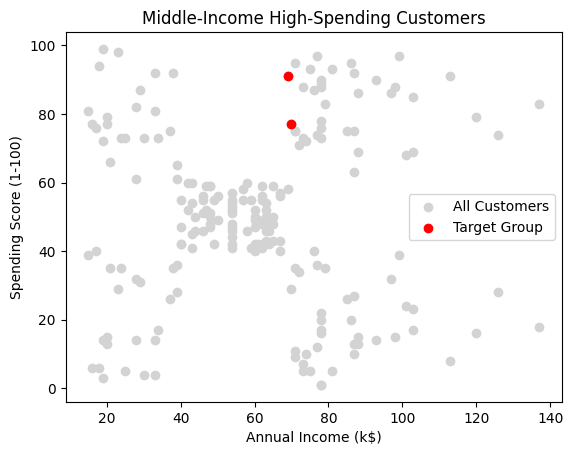

In [33]:
plt.scatter(target_group['Annual Income (k$)'], target_group['Spending Score (1-100)'], 
            color='red', label='Target Group')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Middle-Income High-Spending Customers")
plt.legend()
plt.show()


AgeGroup
<20      51.222222
20-30    48.785714
30-40    54.000000
40-50    48.555556
50-60    51.363636
60+      49.928571
Name: Spending Score (1-100), dtype: float64


C:\Users\Aditya\AppData\Local\Temp\ipykernel_21136\4154865123.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  middle_income['AgeGroup'] = pd.cut(middle_income['Age'],
C:\Users\Aditya\AppData\Local\Temp\ipykernel_21136\4154865123.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_income_spending = middle_income.groupby('AgeGroup')['Spending Score (1-100)'].mean()


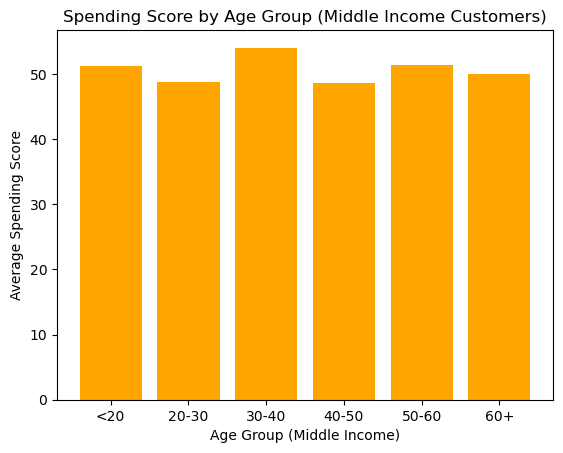

In [14]:
middle_income = df[(df['Annual Income (k$)'] >= 40) & (df['Annual Income (k$)'] <= 70)]
middle_income['AgeGroup'] = pd.cut(middle_income['Age'], 
                                   bins=[0,20,30,40,50,60,70], 
                                   labels=['<20','20-30','30-40','40-50','50-60','60+'])
age_income_spending = middle_income.groupby('AgeGroup')['Spending Score (1-100)'].mean()
print(age_income_spending)
plt.bar(age_income_spending.index.astype(str), age_income_spending.values, color='orange')
plt.xlabel("Age Group (Middle Income)")
plt.ylabel("Average Spending Score")
plt.title("Spending Score by Age Group (Middle Income Customers)")
plt.show()

IncomeGroup
Low Income       49.480000
Middle Income    50.684211
High Income      50.189189
Name: Spending Score (1-100), dtype: float64


C:\Users\aliay\AppData\Local\Temp\ipykernel_22212\2261333567.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_spending = df.groupby('IncomeGroup')['Spending Score (1-100)'].mean()


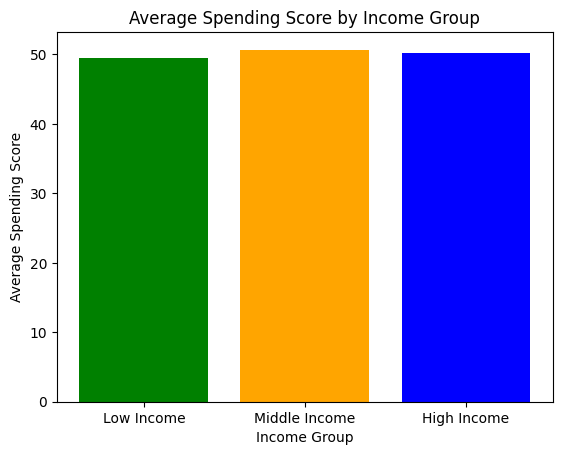

In [35]:
df['IncomeGroup'] = pd.cut(df['Annual Income (k$)'], 
                           bins=[0,40,70,150], 
                           labels=['Low Income','Middle Income','High Income'])
income_spending = df.groupby('IncomeGroup')['Spending Score (1-100)'].mean()

print(income_spending)
plt.bar(income_spending.index.astype(str), income_spending.values, color=['green','orange','blue'])
plt.xlabel("Income Group")
plt.ylabel("Average Spending Score")
plt.title("Average Spending Score by Income Group")
plt.show()
